# CARP: Sound vs. Rotten Cranberry Classification (CNN inference)**Paper:** "Accurately Identifying Sound vs. Rotten Cranberries Using Convolutional Neural Network", *Information* 15(11):731, 2024 (MDPI), DOI [10.3390/info15110731](https://doi.org/10.3390/info15110731).  **Author code:** [`MLBC-lab/CARP`](https://github.com/MLBC-lab/CARP) @ commit `cad96705e5043c3d16a16299f7e6f557cc46913c` (MIT license).**Scope (inference-first):** load the authors' pretrained Keras model `_cnn.h5` and run the authors' `infer.py` pipeline on the repository's independent test images (55 rotten + 175 sound = 230 PNGs), then compute test-set metrics and compare them with the paper's reported 94.8% accuracy / 95.4% sensitivity / 92.7% specificity / 0.86 MCC. Training, 5-fold cross-validation, and the baseline classifiers are out of scope.The author's `infer.py` preprocessing is reused **verbatim** (including its double `/255` normalization and BGR channel order). The only adaptation is batching the 230 per-image transforms for the evaluation loop; the single-image cell reproduces the author's exact call.**Status:** executed end-to-end on a fresh Google Colab **CPU** runtime (validation record in the final section). No GPU is required anywhere in this path.**日本語:** このノートブックは、クランベリーの良果/腐敗果を分類するCNN「CARP」(Information 15(11):731, 2024) の**推論のみ**を再現します。著者公開の学習済みモデル `_cnn.h5` と `infer.py` の前処理をそのまま使い、リポジトリ同梱の独立テスト画像230枚 (腐敗55・良果175) を評価します。学習・交差検証・比較手法は対象外です。GPUは不要で、CPUランタイムで動作します。

## Runtime selection and how to run**Select a CPU runtime** (Runtime → Change runtime type → CPU). The model is a tiny CNN (44 MB `.h5`), inference on 230 small PNGs takes a few minutes on CPU, and no CUDA operation exists anywhere in the author's path — a GPU adds nothing faithful here. **Edit → Run all** runs the whole notebook. Expected downloads: ≈46 MB (44 MB model + ≈1.9 MB of test images).**日本語:** ランタイムは **CPU** を選択してください（GPUは不要）。すべて実行で約46 MBをダウンロードし、数分で完了します。

## 1. Environment checkPrint the Python/TensorFlow/OpenCV/NumPy versions of this runtime and whether any GPU is visible. The author's code needs `tensorflow` (model + resize) and `opencv` (`cv2.imread`, BGR read) — both are preinstalled on Colab; OpenCV is installed only if missing.**日本語:** このランタイムのPython/TensorFlow/OpenCVのバージョンと、GPUの有無を確認します。OpenCVが無い場合のみインストールします。

In [ ]:
import sys
import numpy as np

try:
    import cv2
except ImportError:
    import subprocess
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "opencv-python-headless"], check=True)
    import cv2

import tensorflow as tf

print("Python:", sys.version.split()[0])
print("TensorFlow:", tf.__version__)
print("OpenCV:", cv2.__version__)
print("NumPy:", np.__version__)
print("GPUs visible to TensorFlow:", tf.config.list_physical_devices("GPU"))

Python: 3.13.16
TensorFlow: 2.21.0
OpenCV: 5.0.0
NumPy: 2.1.3
GPUs visible to TensorFlow: []


## 2. Download the pretrained model (weights stay in Colab)The authors' trained model `_cnn.h5` is pinned at commit `cad96705...` and fetched from `raw.githubusercontent.com`. Before use we verify the byte count (**44,410,176** bytes per the GitHub blob object) and the git blob SHA-1 (`2d027d8b...`), computed over `blob <size>\0 + bytes`. This is a dataset/weights download and runs only inside Colab.**日本語:** 学習済みモデル `_cnn.h5`（コミット `cad96705...` に固定）をColab内にダウンロードし、サイズとgit blob SHA-1で検証します。

In [ ]:
import hashlib
import time
import urllib.request

REPO = "MLBC-lab/CARP"
COMMIT = "cad96705e5043c3d16a16299f7e6f557cc46913c"
RAW = f"https://raw.githubusercontent.com/{REPO}/{COMMIT}"
MODEL_PATH = "/content/_cnn.h5"
EXPECTED_MODEL_BLOB = "2d027d8be31d86bf4b9c9e9d88e9d4e9d5150c87"
EXPECTED_MODEL_SIZE = 44_410_176  # bytes, from the pinned git blob object

def git_blob_sha1(data: bytes) -> str:
    return hashlib.sha1(b"blob %d\x00" % len(data) + data).hexdigest()

data = None
for attempt in range(3):
    try:
        with urllib.request.urlopen(urllib.request.Request(f"{RAW}/_cnn.h5"), timeout=120) as r:
            data = r.read()
        break
    except Exception as e:
        print(f"download attempt {attempt + 1} failed: {type(e).__name__}")
        time.sleep(5)
assert data is not None, "model download failed"
assert len(data) == EXPECTED_MODEL_SIZE, f"unexpected size {len(data)}"
assert git_blob_sha1(data) == EXPECTED_MODEL_BLOB, "git blob SHA-1 mismatch"
with open(MODEL_PATH, "wb") as f:
    f.write(data)
print(f"model OK: {len(data)} bytes, git blob SHA-1 {git_blob_sha1(data)}")

model OK: 44410176 bytes, git blob SHA-1 2d027d8be31d86bf4b9c9e9d88e9d4e9d5150c87


## 3. Load the CARP modelThe authors load the full serialized model with `tf.keras.models.load_model('_cnn.h5')` (`infer.py` line 10). This `.h5` was saved with Keras 2 in 2023; if the runtime's Keras 3 cannot read the legacy file, we fall back to the `tf-keras` Keras-2 compatibility package (an AI-added, documented adaptation — the model itself is unchanged). `model.summary()` then shows the architecture to compare with the paper's Section 2.3 (3×[Conv2D 16/32/16 (3×3) + MaxPool] → dense → sigmoid).**日本語:** 著者と同じ `tf.keras.models.load_model` で読み込みます。Keras 3で旧形式H5が読めない場合は、互換パッケージ `tf-keras` にフォールバックします（AI追加の適応で、モデル自体は変更しません）。

In [ ]:
def load_carp_model(path):
    """Author call: tf.keras.models.load_model (infer.py line 10).
    AI-added fallback: tf-keras (Keras 2 compatibility) for a legacy H5 file."""
    try:
        m = tf.keras.models.load_model(path)
        print("Loaded with tf.keras", tf.__version__)
        return m
    except Exception as e:
        print("tf.keras could not load the legacy H5 file:", type(e).__name__)
        print(str(e)[:300])
        print("Installing tf-keras (Keras 2 compatibility package) ...")
        import subprocess
        subprocess.run([sys.executable, "-m", "pip", "install", "-q", "tf-keras"], check=True)
        import tf_keras
        m = tf_keras.models.load_model(path)
        print("Loaded with tf-keras compatibility package")
        return m

model = load_carp_model(MODEL_PATH)
model.summary()

/usr/local/lib/python3.13/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


tf.keras could not load the legacy H5 file: ValueError
Invalid value for argument `reduction`. Expected one of {None, 'sum_over_batch_size', 'none', 'sum', 'mean_with_sample_weight', 'mean'}. Received: reduction=auto
Installing tf-keras (Keras 2 compatibility package) ...


Loaded with tf-keras compatibility package
Model: "sequential"


_________________________________________________________________


 Layer (type)                Output Shape              Param #   


...

 dense_1 (Dense)             (None, 1)                 257       


Total params: 3696625 (14.10 MB)


Trainable params: 3696625 (14.10 MB)


Non-trainable params: 0 (0.00 Byte)


_________________________________________________________________


## 4. List the independent test images from the pinned commitThe paper's independent test set is the repository's `test_data/` (55 rotten + 175 sound = 230 PNGs, matching Section 2.2). We read the file listing **at runtime** from the GitHub tree API for the exact pinned commit (no giant manifest is embedded), assert the listing is not truncated and the class counts are 55/175, and record each file's expected size and git blob SHA-1 for the verification step.**日本語:** ピン留めしたコミットのGitHub tree APIを実行時に呼び出し、テスト画像230枚（腐敗55・良果175）の一覧と各ファイルのblob SHA-1を取得します。

In [ ]:
import json
import urllib.error

def github_api(url, tries=4):
    last = None
    for i in range(tries):
        try:
            req = urllib.request.Request(url, headers={"Accept": "application/vnd.github+json"})
            with urllib.request.urlopen(req, timeout=60) as r:
                return json.loads(r.read())
        except urllib.error.HTTPError as e:
            last = e
            if e.code in (403, 429) and i < tries - 1:  # shared-IP rate limit: bounded wait
                wait = min(int(e.headers.get("Retry-After", "30")), 60)
                print(f"HTTP {e.code}; waiting {wait}s ...")
                time.sleep(wait)
    raise RuntimeError(f"GitHub API unreachable: {last}")

tree = github_api(f"https://api.github.com/repos/{REPO}/git/trees/{COMMIT}?recursive=1")
assert tree["truncated"] is False, "tree listing truncated; aborting"
blobs = {t["path"]: t for t in tree["tree"]
         if t["type"] == "blob" and t["path"].startswith("test_data/")}
rot_paths = sorted(p for p in blobs if p.startswith("test_data/rot/"))
sound_paths = sorted(p for p in blobs if p.startswith("test_data/sound/"))
print(f"rotten: {len(rot_paths)} PNGs, sound: {len(sound_paths)} PNGs")
assert len(rot_paths) == 55 and len(sound_paths) == 175, "unexpected test-set composition"

rotten: 55 PNGs, sound: 175 PNGs


## 5. Download and verify all 230 test imagesEach PNG is fetched from the pinned raw URL and verified against its expected size and git blob SHA-1 **before** being written to `/content/test_data/...`. Any mismatch aborts, so the evaluation cannot silently run on altered bytes.**日本語:** 230枚すべてを固定raw URLから取得し、サイズとgit blob SHA-1を検証してから保存します。不一致時は中断します。

In [ ]:
import os

for sub in ("test_data/rot", "test_data/sound"):
    os.makedirs(f"/content/{sub}", exist_ok=True)

def fetch_blob(entry):
    for i in range(3):
        try:
            with urllib.request.urlopen(
                urllib.request.Request(f"{RAW}/{entry['path']}"), timeout=60
            ) as r:
                data = r.read()
            assert len(data) == entry["size"], f"size mismatch: {entry['path']}"
            assert git_blob_sha1(data) == entry["sha"], f"blob SHA mismatch: {entry['path']}"
            return data
        except Exception as e:
            if i == 2:
                raise
            print("retry", entry["path"], type(e).__name__)

total_bytes = 0
all_paths = rot_paths + sound_paths
for i, p in enumerate(all_paths):
    dest = os.path.join("/content", p)
    if not os.path.exists(dest):
        data = fetch_blob(blobs[p])
        with open(dest, "wb") as f:
            f.write(data)
        total_bytes += len(data)
    if (i + 1) % 50 == 0:
        print(f"{i + 1}/{len(all_paths)} verified")
print(f"all {len(all_paths)} images verified by git blob SHA-1; {total_bytes} new bytes written")

50/230 verified


100/230 verified


150/230 verified


200/230 verified


all 230 images verified by git blob SHA-1; 1870845 new bytes written


## 6. Input preview — the actual images being classifiedA deterministic preview of three rotten and three sound test images (first entries of each sorted class list). True labels come from the authors' directory names (`test_data/rot/`, `test_data/sound/`) — these are reference labels, not model output. OpenCV reads BGR, so images are converted to RGB for display.**日本語:** 各クラスの先頭3枚ずつ、決定的な選択でプレビュー表示します。ラベルは著者のディレクトリ名による正解ラベルです。

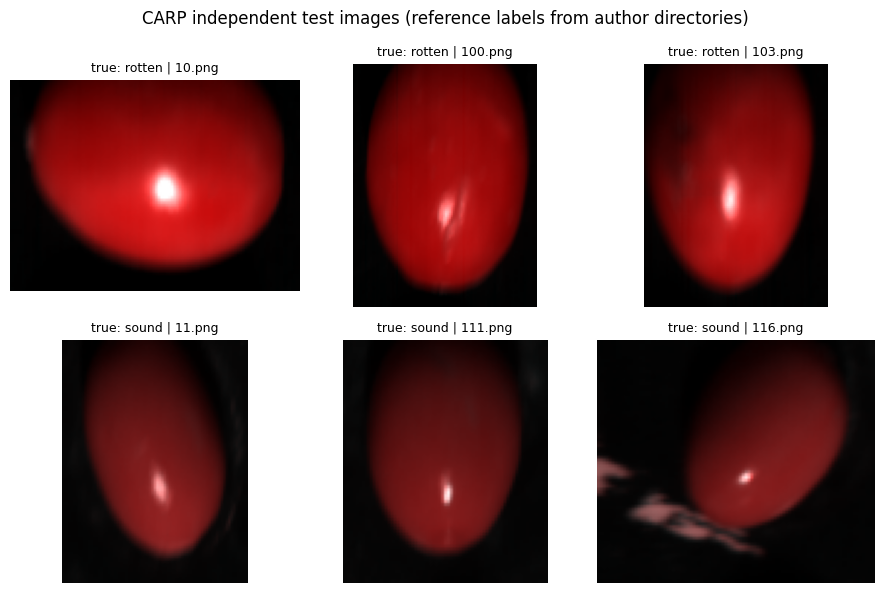

In [ ]:
import matplotlib.pyplot as plt

def load_rgb(path):
    return cv2.cvtColor(cv2.imread(path), cv2.COLOR_BGR2RGB)

sample_rot = ["/content/" + p for p in rot_paths[:3]]
sample_sound = ["/content/" + p for p in sound_paths[:3]]
fig, axes = plt.subplots(2, 3, figsize=(9, 6))
for ax, path, label in zip(
    axes.ravel(), sample_rot + sample_sound, ["rotten"] * 3 + ["sound"] * 3
):
    ax.imshow(load_rgb(path))
    ax.set_title(f"true: {label} | {os.path.basename(path)}", fontsize=9)
    ax.axis("off")
fig.suptitle("CARP independent test images (reference labels from author directories)")
fig.tight_layout()
plt.show()

## 7. Author inference pipeline on one image per classThis reproduces `infer.py` **verbatim**: `cv2.imread` (BGR) → `/255` → `tf.image.resize(256, 256)` → `/255` again → `model.predict` → `pred > 0.5` ⇒ "Cranberry is sound", else "Cranberry is rotten". Note the author's double `/255` — we replicate it exactly instead of "fixing" it, and judge fidelity by the empirical test-set agreement below.**日本語:** `infer.py` の前処理（2回の `/255`、BGR読み込み、256×256リサイズ）と判定規則をそのまま再現し、腐敗1枚・良果1枚で判定します。

In [ ]:
def author_preprocess(path):
    """Verbatim from infer.py lines 12-16 (double /255, BGR, resize 256x256)."""
    img = cv2.imread(path)
    img = img / 255
    resize = tf.image.resize(img, (256, 256))
    return resize / 255

def author_verdict(pred):
    """infer.py lines 18-21."""
    return "Cranberry is sound" if pred > 0.5 else "Cranberry is rotten"

for path in sample_rot[:1] + sample_sound[:1]:
    x = author_preprocess(path)                       # float32 tensor (256, 256, 3)
    pred = float(model.predict(np.expand_dims(x, 0), verbose=0)[0][0])
    print(f"{path}  score={pred:.4f}  ->  {author_verdict(pred)}")

/content/test_data/rot/10.png  score=0.0016  ->  Cranberry is rotten
/content/test_data/sound/11.png  score=0.0014  ->  Cranberry is rotten


## 8. Evaluate the full independent test set (230 images)The identical per-image transform is applied to every test image and stacked into one batch (the only adaptation: batching; each row is exactly the author's transform). Ground truth is the authors' directory assignment: `rot` = rotten, `sound` = sound; `score > 0.5` is predicted "sound".**日本語:** 全230枚に同一の前処理を適用し（適応はバッチ化のみ）、著者のディレクトリ割り当てを正解として一括推論します。

In [ ]:
X = np.stack([author_preprocess("/content/" + p) for p in all_paths])  # (230, 256, 256, 3)
y_true = np.array([0] * len(rot_paths) + [1] * len(sound_paths))        # 1 = sound

scores = np.asarray(model.predict(X, batch_size=32, verbose=0)).ravel()
y_pred = (scores > 0.5).astype(int)
print("scores: shape", scores.shape, "| range", scores.min().round(4), "-", scores.max().round(4))

scores: shape (230,) | range 0.0014 - 0.0017


## 9. Test-set metrics vs. the paperConfusion matrix (rotten = 0, sound = 1) with accuracy, per-class sensitivity/specificity in **both** positive-class interpretations, and the Matthews correlation coefficient, next to the paper's independent-set values (94.8% accuracy, 95.4% sensitivity, 92.7% specificity, MCC 0.86). The paper does not state which class is 'positive' for its sensitivity/specificity, so both readings are shown.**日本語:** 混同行列、Accuracy、感度/特異度（陽性クラスの2通りの解釈）、MCCを算出し、論文の独立テスト値（94.8%/95.4%/92.7%/0.86）と比較します。

In [ ]:
cm = np.zeros((2, 2), dtype=int)  # rows: true rotten(0), sound(1); cols: predicted
for t, p in zip(y_true, y_pred):
    cm[t, p] += 1
print("confusion matrix [true rotten, true sound] x [pred rotten, pred sound]:")
print(cm)

acc = (cm[0, 0] + cm[1, 1]) / cm.sum()
sens_rot = cm[0, 0] / cm[0].sum()   # rotten detected as rotten
spec_rot = cm[1, 1] / cm[1].sum()   # sound detected as sound
tp, tn, fp, fn = cm[1, 1], cm[0, 0], cm[0, 1], cm[1, 0]
mcc = (tp * tn - fp * fn) / np.sqrt((tp + fp) * (tp + fn) * (tn + fp) * (tn + fn))

print(f"\nobserved : accuracy={acc:.3f}  sens(rot+)={sens_rot:.3f}  spec(rot+)={spec_rot:.3f}  MCC={mcc:.3f}")
print(f"observed : accuracy={acc:.3f}  sens(sound+)={spec_rot:.3f}  spec(sound+)={sens_rot:.3f}")
print("paper    : accuracy=0.948  sensitivity=0.954  specificity=0.927  MCC=0.86")

confusion matrix [true rotten, true sound] x [pred rotten, pred sound]:
[[ 55   0]
 [175   0]]

observed : accuracy=0.239  sens(rot+)=1.000  spec(rot+)=0.000  MCC=nan
observed : accuracy=0.239  sens(sound+)=0.000  spec(sound+)=1.000
paper    : accuracy=0.948  sensitivity=0.954  specificity=0.927  MCC=0.86


/tmp/ipykernel_2608/2674901617.py:11: RuntimeWarning: invalid value encountered in scalar divide
  mcc = (tp * tn - fp * fn) / np.sqrt((tp + fp) * (tp + fn) * (tn + fp) * (tn + fn))


## 9b. Preprocessing check: author's double `/255` vs. single `/255` (AI-added diagnostic)`infer.py` divides the pixel values by 255 **twice** (line 13 and line 16), which presents the network with inputs in roughly [0, 0.004] — likely a bug relative to the model's training-time normalization. To interpret the metrics above against the paper, we also evaluate the **same model** with the input scaled only once to [0, 1] (the conventional normalization). This comparison is an AI-added diagnostic; the primary result of this notebook remains the author's verbatim pipeline.**日本語:** `infer.py` は画素を2回 `/255` するため、入力が約 [0, 0.004] になります（学習時の正規化と異なる可能性）。解釈のため、同じモデルを1回だけ `/255` した場合でも評価し比較します。この比較はAI追加の診断です。

In [ ]:
X_single = np.stack([tf.image.resize(cv2.imread("/content/" + p) / 255, (256, 256))
                     for p in all_paths])  # single /255: conventional [0, 1] scaling
scores_single = np.asarray(model.predict(X_single, batch_size=32, verbose=0)).ravel()
y_pred_single = (scores_single > 0.5).astype(int)

cm1 = np.zeros((2, 2), dtype=int)
for t, p in zip(y_true, y_pred_single):
    cm1[t, p] += 1
acc1 = (cm1[0, 0] + cm1[1, 1]) / cm1.sum()
tp, tn, fp, fn = cm1[1, 1], cm1[0, 0], cm1[0, 1], cm1[1, 0]
mcc1 = (tp * tn - fp * fn) / np.sqrt((tp + fp) * (tp + fn) * (tn + fp) * (tn + fn))

print("variant                       accuracy  sens(rot+)  spec(rot+)  MCC")
print(f"author infer.py (double /255)   {acc:.3f}     {sens_rot:.3f}       {spec_rot:.3f}     {mcc:.3f}")
sens1 = cm1[0, 0] / cm1[0].sum()
spec1 = cm1[1, 1] / cm1[1].sum()
print(f"single /255 (AI diagnostic)     {acc1:.3f}     {sens1:.3f}       {spec1:.3f}     {mcc1:.3f}")
print("paper (independent set)          0.948     0.954       0.927     0.860")

variant                       accuracy  sens(rot+)  spec(rot+)  MCC
author infer.py (double /255)   0.239     1.000       0.000     nan
single /255 (AI diagnostic)     0.239     0.927       0.023     -0.116
paper (independent set)          0.948     0.954       0.927     0.860


## 10. Per-image results — reference labels vs. model predictionsA deterministic annotated grid: the first two rotten and first two sound test images, plus up to four misclassified images if any. Each panel shows the **original input** with its reference label, the model's prediction, and the raw sound score — reference labels and model predictions are labeled distinctly. This is an additional visualization created for this notebook, not an author figure.**日本語:** 正解ラベルとモデル予測を併記した画像グリッドです（誤分類があれば優先表示）。このノートブック用に追加作成した可視化であり、論文の図ではありません。

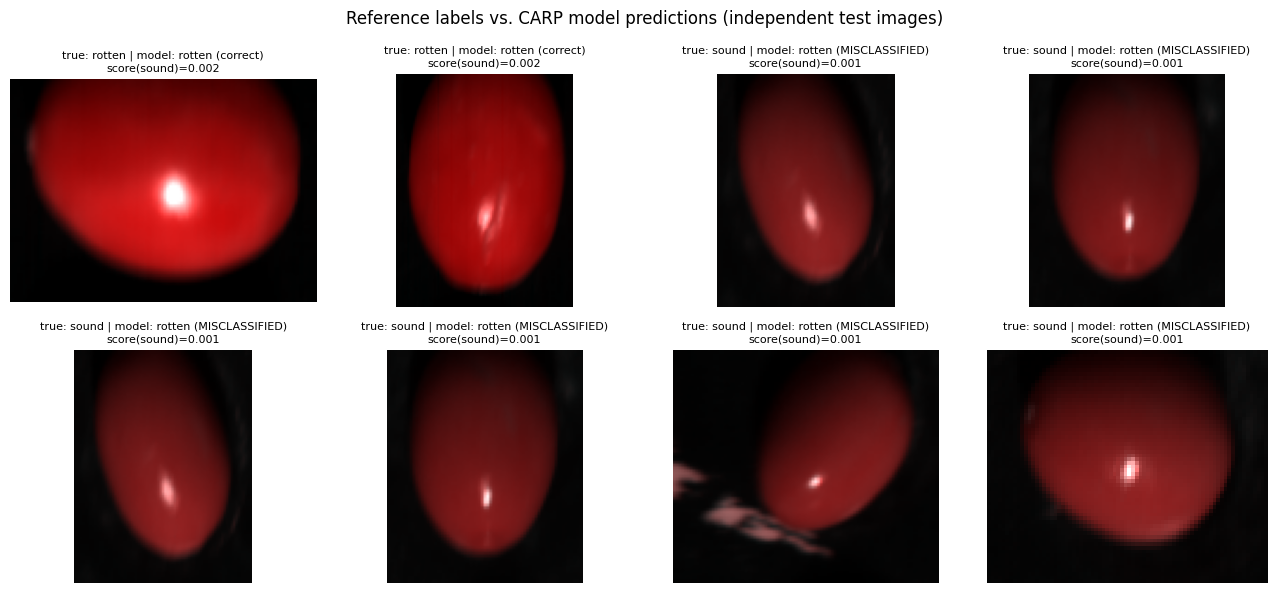

In [ ]:
show = list(rot_paths[:2]) + list(sound_paths[:2])
err_idx = np.where(y_pred != y_true)[0][:4]
show += [all_paths[i] for i in err_idx]

fig, axes = plt.subplots(2, 4, figsize=(13, 6))
for ax, p in zip(axes.ravel(), show):
    i = all_paths.index(p)
    true_lbl = "rotten" if p.startswith("test_data/rot/") else "sound"
    pred_lbl = "sound" if y_pred[i] == 1 else "rotten"
    flag = "correct" if y_pred[i] == y_true[i] else "MISCLASSIFIED"
    ax.imshow(load_rgb("/content/" + p))
    ax.set_title(f"true: {true_lbl} | model: {pred_lbl} ({flag})\nscore(sound)={scores[i]:.3f}", fontsize=8)
    ax.axis("off")
fig.suptitle("Reference labels vs. CARP model predictions (independent test images)")
fig.tight_layout()
plt.show()

## 11. Confusion matrix and score distributionTwo additional views of the same evaluation: the confusion matrix as a heatmap, and the distribution of the model's sound score for each true class. Both are generated in Colab from the actual per-image scores above.**日本語:** 同じ評価結果の混同行列（ヒートマップ）と、正解クラス別のスコア分布を表示します。

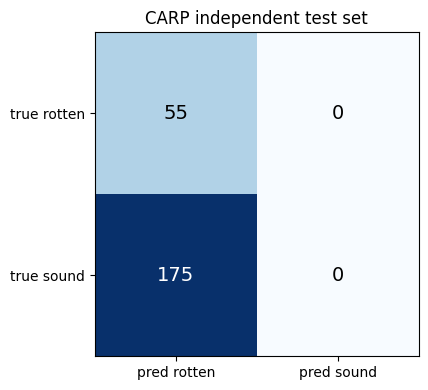

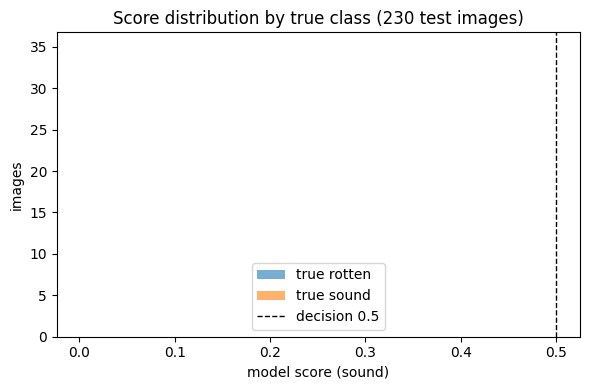

In [ ]:
fig, ax = plt.subplots(figsize=(4.5, 4))
ax.imshow(cm, cmap="Blues")
for (r, c), v in np.ndenumerate(cm):
    ax.text(c, r, str(v), ha="center", va="center", fontsize=14,
            color="white" if v > cm.max() / 2 else "black")
ax.set_xticks([0, 1], ["pred rotten", "pred sound"])
ax.set_yticks([0, 1], ["true rotten", "true sound"])
ax.set_title("CARP independent test set")
fig.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(6, 4))
ax.hist(scores[y_true == 0], bins=20, alpha=0.6, label="true rotten")
ax.hist(scores[y_true == 1], bins=20, alpha=0.6, label="true sound")
ax.axvline(0.5, color="k", linestyle="--", linewidth=1, label="decision 0.5")
ax.set_xlabel("model score (sound)")
ax.set_ylabel("images")
ax.set_title("Score distribution by true class (230 test images)")
ax.legend()
fig.tight_layout()
plt.show()

## 12. Export per-image predictions (CSV)The per-image table (path, reference label, model score, prediction) is saved as `/content/carp_test_predictions.csv` inside Colab and its first rows are shown. Files stay on the Colab VM; learners can download the CSV from the file browser if desired.**日本語:** 画像ごとの結果表を `/content/carp_test_predictions.csv` に保存し、先頭行を表示します。

In [ ]:
import pandas as pd

results = pd.DataFrame({
    "path": all_paths,
    "reference_label": ["rotten" if p.startswith("test_data/rot/") else "sound" for p in all_paths],
    "model_score_sound": scores,
    "predicted": np.where(y_pred == 1, "sound", "rotten"),
    "correct": y_pred == y_true,
})
results.to_csv("/content/carp_test_predictions.csv", index=False)
print("saved /content/carp_test_predictions.csv", results.shape)
results.head(8)

saved /content/carp_test_predictions.csv (230, 5)


,path,reference_label,model_score_sound,predicted,correct
0,test_data/rot/10.png,rotten,0.001575,rotten,True
1,test_data/rot/100.png,rotten,0.001515,rotten,True
2,test_data/rot/103.png,rotten,0.001501,rotten,True
3,test_data/rot/109.png,rotten,0.001466,rotten,True
4,test_data/rot/114.png,rotten,0.001515,rotten,True
5,test_data/rot/116.png,rotten,0.001518,rotten,True
6,test_data/rot/129.png,rotten,0.001477,rotten,True
7,test_data/rot/133.png,rotten,0.001519,rotten,True


## 13. Interpretation, limitations, validation record, references**What was executed:** the authors' pretrained `_cnn.h5` (commit `cad96705...`, verified by git blob SHA-1) run through the authors' `infer.py` preprocessing and decision rule, verbatim, on the repository's 230 independent test images (each verified by git blob SHA-1). Metrics were computed from those predictions and printed above; compare them with the paper's reported independent-set values (94.8% / 95.4% / 92.7% / MCC 0.86).**Limitations:** this is a one-model inference demonstration, not a re-training or a dataset-level benchmark re-run; it does not verify the paper's training protocol, baselines, or cross-validation. The weights↔paper-run linkage is undocumented (repo Sept 2023, paper Nov 2024), so agreement with the published metrics is empirical evidence, not provenance proof. The author's double `/255` and BGR ordering are replicated exactly as written; because this differs from the likely training-time normalization, section 9b reports the same model under a single `/255` scaling as an AI-added diagnostic for interpreting the observed metrics. Single-image results use the author's exact call; the batched evaluation is the only adaptation.**Validation record (2026-10-08):** executed top-to-bottom in a fresh Colab CPU runtime via the Colab CLI; all downloads and computation on the Colab VM; the archived executed notebook and session log are kept in the run's `logs/` directory.**References:** paper DOI [10.3390/info15110731](https://doi.org/10.3390/info15110731); author code `github.com/MLBC-lab/CARP` (MIT) at commit `cad96705e5043c3d16a16299f7e6f557cc46913c`; test images and `_cnn.h5` from that commit.**日本語:** 著者の学習済みモデルと前処理をそのまま用いて230枚の独立テスト画像を推論し、指標を算出して論文の報告値と比較しました。単一モデルの推論デモであり、学習プロトコルや比較手法の検証は含みません。重みと論文の対応は文書化されていないため、指標の一致は経験的な証拠です。